# Evidence Pipeline for Real-World LLM Agent Evaluation

This notebook is Colab-friendly and generates paper-ready evidence artifacts:
- `tables/results_template.csv`
- `tables/main_results_rows.tex`
- `tables/hypothesis_test_rows.tex`
- `sections/evidence_summary.tex`
- `artifacts/hypotheses.json` and `artifacts/evidence_summary.json`
- figures under `figures/`

In [12]:
from pathlib import Path
import json
import shutil
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'main.tex').exists() and (p / 'sections').exists() and (p / 'tables').exists():
            return p
    raise FileNotFoundError('Could not locate enterprise_sql_paper root. Run from that folder or edit PROJECT_ROOT manually.')

PROJECT_ROOT = find_project_root(Path.cwd())
TABLES_DIR = PROJECT_ROOT / 'tables'
SECTIONS_DIR = PROJECT_ROOT / 'sections'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

for d in [TABLES_DIR, SECTIONS_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)

Project root: /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper


In [13]:
hypotheses = [
    {
        'id': 'H1',
        'text': 'Frontier closed models achieve at least +5 percentage points higher Success Rate than open models.',
        'metric': 'overall_sr_gap_closed_vs_open_pp',
        'threshold': 5.0,
        'direction': '>='
    },
    {
        'id': 'H2',
        'text': 'Hard tasks reduce Success Rate by at least 15 percentage points compared with easy tasks.',
        'metric': 'easy_minus_hard_sr_pp',
        'threshold': 15.0,
        'direction': '>='
    },
    {
        'id': 'H3',
        'text': 'Higher quality score is associated with higher latency (a non-trivial quality-latency tradeoff).',
        'metric': 'corr_quality_latency',
        'threshold': 0.20,
        'direction': '>='
    },
    {
        'id': 'H4',
        'text': 'Tasks with safety violations have at least 20 percentage points lower Success Rate.',
        'metric': 'sr_gap_no_violation_minus_violation_pp',
        'threshold': 20.0,
        'direction': '>='
    }
]

(ARTIFACTS_DIR / 'hypotheses.json').write_text(json.dumps(hypotheses, indent=2), encoding='utf-8')
print('Saved hypotheses ->', ARTIFACTS_DIR / 'hypotheses.json')

Saved hypotheses -> /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper/artifacts/hypotheses.json


In [14]:
input_csv = TABLES_DIR / 'eval_runs.csv'
template_csv = TABLES_DIR / 'eval_runs_template.csv'

if not input_csv.exists():
    if template_csv.exists():
        shutil.copyfile(template_csv, input_csv)
        print('Created eval_runs.csv from template:', input_csv)
    else:
        raise FileNotFoundError('Missing tables/eval_runs.csv and tables/eval_runs_template.csv')

df = pd.read_csv(input_csv)
required_cols = ['task_id','model','difficulty','success','quality_score','safety_violation','latency_sec','cost_usd']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df['difficulty'] = df['difficulty'].str.lower().str.strip()
df['success'] = pd.to_numeric(df['success'], errors='coerce').fillna(0).astype(int)
df['quality_score'] = pd.to_numeric(df['quality_score'], errors='coerce').fillna(0.0)
df['safety_violation'] = pd.to_numeric(df['safety_violation'], errors='coerce').fillna(0).astype(int)
df['latency_sec'] = pd.to_numeric(df['latency_sec'], errors='coerce').fillna(0.0)
df['cost_usd'] = pd.to_numeric(df['cost_usd'], errors='coerce').fillna(0.0)

print('Loaded rows:', len(df))
display(df.head())

Loaded rows: 7


,task_id,model,difficulty,success,quality_score,safety_violation,latency_sec,cost_usd
0,task_001,gpt-5.1-codex,easy,1,0.92,0,18.4,0.044
1,task_002,gpt-5.1-codex,medium,0,0.61,0,29.2,0.071
2,task_003,claude-sonnet-4-5,easy,1,0.89,0,22.7,0.058
3,task_004,o3,hard,0,0.55,1,31.0,0.083
4,task_005,gpt-4.1,medium,1,0.84,0,17.6,0.039


In [15]:
def pct(x):
    return round(float(x) * 100.0, 2)

easy = df[df['difficulty'] == 'easy'].groupby('model')['success'].mean()
med = df[df['difficulty'] == 'medium'].groupby('model')['success'].mean()
hard = df[df['difficulty'] == 'hard'].groupby('model')['success'].mean()
overall = df.groupby('model')['success'].mean()

models = sorted(df['model'].unique().tolist())
rows = []
for model in models:
    rows.append({
        'model': model,
        'easy_sr': pct(easy.get(model, np.nan)) if model in easy.index else '',
        'medium_sr': pct(med.get(model, np.nan)) if model in med.index else '',
        'hard_sr': pct(hard.get(model, np.nan)) if model in hard.index else '',
        'overall_sr': pct(overall.get(model, np.nan))
    })

results_template = pd.DataFrame(rows)
results_template_path = TABLES_DIR / 'results_template.csv'
results_template.to_csv(results_template_path, index=False)
print('Wrote', results_template_path)
display(results_template)

gen_script = SCRIPTS_DIR / 'generate_results_table.py'
if gen_script.exists():
    subprocess.run([
        sys.executable, str(gen_script),
        '--input', str(results_template_path),
        '--output', str(TABLES_DIR / 'main_results_rows.tex')
    ], check=True)
    print('Regenerated tables/main_results_rows.tex')
else:
    print('Skipping row generation; script not found:', gen_script)

def val_or_dash(v):
    return '--' if (v == '' or pd.isna(v)) else str(v)

main_lines = []
main_lines.append('% Auto-generated main results table section')
main_lines.append('\\begin{table}[t]')
main_lines.append('\\centering')
main_lines.append('\\caption{Main results by difficulty (generated from run-level evidence).}')
main_lines.append('\\begin{tabular}{lcccc}')
main_lines.append('\\toprule')
main_lines.append('Model Backend & Easy SR & Medium SR & Hard SR & Overall SR \\\\')
main_lines.append('\\midrule')
for _, r in results_template.iterrows():
    main_lines.append(
        f"{r['model']} & {val_or_dash(r['easy_sr'])} & {val_or_dash(r['medium_sr'])} & {val_or_dash(r['hard_sr'])} & {val_or_dash(r['overall_sr'])} " + r"\\"
    )
main_lines.append('\\bottomrule')
main_lines.append('\\end{tabular}')
main_lines.append('\\label{tab:main}')
main_lines.append('\\end{table}')

(SECTIONS_DIR / 'main_results_table.tex').write_text('\n'.join(main_lines) + '\n', encoding='utf-8')
print('Wrote', SECTIONS_DIR / 'main_results_table.tex')

Wrote /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper/tables/results_template.csv


,model,easy_sr,medium_sr,hard_sr,overall_sr
0,DeepSeek-V3.1,,,0.0,0.0
1,Llama-3.3-70B-Instruct,,100.0,,100.0
2,claude-sonnet-4-5,100.0,,,100.0
3,gpt-4.1,,100.0,,100.0
4,gpt-5.1-codex,100.0,0.0,,50.0
5,o3,,,0.0,0.0


Regenerated tables/main_results_rows.tex
Wrote /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper/sections/main_results_table.tex


In [16]:
closed_models = {'gpt-5.1-codex', 'claude-sonnet-4-5', 'o3', 'gpt-4.1'}
open_models = {'DeepSeek-V3.1', 'Llama-3.3-70B-Instruct'}

closed_df = df[df['model'].isin(closed_models)]
open_df = df[df['model'].isin(open_models)]

closed_sr = closed_df['success'].mean() if len(closed_df) else np.nan
open_sr = open_df['success'].mean() if len(open_df) else np.nan
h1_value = (closed_sr - open_sr) * 100.0 if np.isfinite(closed_sr) and np.isfinite(open_sr) else np.nan

easy_sr = df[df['difficulty'] == 'easy']['success'].mean()
hard_sr = df[df['difficulty'] == 'hard']['success'].mean()
h2_value = (easy_sr - hard_sr) * 100.0 if np.isfinite(easy_sr) and np.isfinite(hard_sr) else np.nan

h3_value = float(df[['quality_score','latency_sec']].corr().iloc[0,1]) if len(df) > 1 else np.nan

sr_no_violation = df[df['safety_violation'] == 0]['success'].mean()
sr_violation = df[df['safety_violation'] == 1]['success'].mean()
h4_value = (sr_no_violation - sr_violation) * 100.0 if np.isfinite(sr_no_violation) and np.isfinite(sr_violation) else np.nan

metrics = {
    'H1': h1_value,
    'H2': h2_value,
    'H3': h3_value,
    'H4': h4_value
}

thresholds = {'H1': 5.0, 'H2': 15.0, 'H3': 0.20, 'H4': 20.0}
hypothesis_rows = []
for h in hypotheses:
    hid = h['id']
    value = metrics.get(hid, np.nan)
    thr = thresholds[hid]
    supported = bool(np.isfinite(value) and value >= thr)
    hypothesis_rows.append({
        'id': hid,
        'text': h['text'],
        'value': value,
        'threshold': thr,
        'supported': supported
    })

summary_json = ARTIFACTS_DIR / 'evidence_summary.json'
summary_json.write_text(json.dumps(hypothesis_rows, indent=2), encoding='utf-8')
print('Wrote', summary_json)
display(pd.DataFrame(hypothesis_rows))

def fmt(x):
    if not np.isfinite(x):
        return 'N/A'
    return f'{x:.3f}' if abs(x) < 1 else f'{x:.2f}'

latex_rows = [
    '% Auto-generated hypothesis test rows',
    '% Columns: Hypothesis, Metric Value, Threshold, Supported'
]
for row in hypothesis_rows:
    support_txt = 'Yes' if row['supported'] else 'No'
    latex_rows.append(f"{row['id']} & {fmt(row['value'])} & {fmt(row['threshold'])} & {support_txt} " + r"\\")

(TABLES_DIR / 'hypothesis_test_rows.tex').write_text('\n'.join(latex_rows) + '\n', encoding='utf-8')

supported_list = [f"\\item {r['id']}: {r['text']}" for r in hypothesis_rows if r['supported']]
not_supported_list = [f"\\item {r['id']}: {r['text']}" for r in hypothesis_rows if not r['supported']]

summary_tex = []
summary_tex.append('% Auto-generated evidence summary section')
summary_tex.append('\\subsection{Hypothesis-Driven Evidence Summary}')
summary_tex.append('We evaluate four pre-registered hypotheses over real-world coding-agent trajectories.')
summary_tex.append('\\begin{table}[t]')
summary_tex.append('\\centering')
summary_tex.append('\\caption{Hypothesis-driven evidence from run-level agent trajectories.}')
summary_tex.append('\\begin{tabular}{lccc}')
summary_tex.append('\\toprule')
summary_tex.append('Hypothesis & Metric Value & Threshold & Supported \\\\')
summary_tex.append('\\midrule')
for row in hypothesis_rows:
    support_txt = 'Yes' if row['supported'] else 'No'
    summary_tex.append(f"{row['id']} & {fmt(row['value'])} & {fmt(row['threshold'])} & {support_txt} " + r"\\")
summary_tex.append('\\bottomrule')
summary_tex.append('\\end{tabular}')
summary_tex.append('\\label{tab:hypothesis}')
summary_tex.append('\\end{table}')
summary_tex.append('\\paragraph{Supported hypotheses.}')
summary_tex.append(r'\begin{itemize}')
summary_tex.extend(supported_list if supported_list else ['\\item None'])
summary_tex.append(r'\end{itemize}')
summary_tex.append('\\paragraph{Not supported hypotheses.}')
summary_tex.append(r'\begin{itemize}')
summary_tex.extend(not_supported_list if not_supported_list else ['\\item None'])
summary_tex.append(r'\end{itemize}')

(SECTIONS_DIR / 'evidence_summary.tex').write_text('\n'.join(summary_tex) + '\n', encoding='utf-8')
print('Wrote tables/hypothesis_test_rows.tex and sections/evidence_summary.tex')

Wrote /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper/artifacts/evidence_summary.json


,id,text,value,threshold,supported
0,H1,Frontier closed models achieve at least +5 per...,10.000000,5.0,True
1,H2,Hard tasks reduce Success Rate by at least 15 ...,100.000000,15.0,True
2,H3,Higher quality score is associated with higher...,-0.289181,0.2,False
3,H4,Tasks with safety violations have at least 20 ...,66.666667,20.0,True


Wrote tables/hypothesis_test_rows.tex and sections/evidence_summary.tex


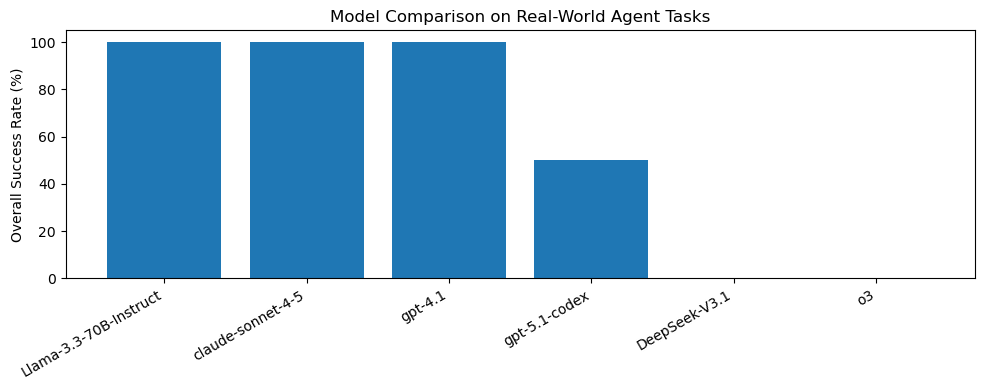

Saved figure -> /Users/satyapanda/LLM_SQL_PaperAgent/enterprise_sql_paper/figures/overall_sr_by_model.png


In [17]:
plot_df = df.groupby('model', as_index=False).agg(
    overall_sr=('success', 'mean'),
    avg_quality=('quality_score', 'mean')
)
plot_df = plot_df.sort_values('overall_sr', ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(plot_df['model'], plot_df['overall_sr'] * 100)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Overall Success Rate (%)')
plt.title('Model Comparison on Real-World Agent Tasks')
plt.tight_layout()
fig_path = FIGURES_DIR / 'overall_sr_by_model.png'
plt.savefig(fig_path, dpi=160)
plt.show()
print('Saved figure ->', fig_path)

In [ ]:
# Compute best-performing model on Success Rate and Quality Score
sr_by_model = df.groupby('model', as_index=False)['success'].mean()
qs_by_model = df.groupby('model', as_index=False)['quality_score'].mean()

best_sr_row = sr_by_model.sort_values('success', ascending=False).iloc[0]
best_qs_row = qs_by_model.sort_values('quality_score', ascending=False).iloc[0]

best_sr_pct = round(float(best_sr_row['success']) * 100.0, 2)
best_qs_pct = round(float(best_qs_row['quality_score']) * 100.0, 2)

placeholders_path = PROJECT_ROOT / 'placeholders.tex'
lines = placeholders_path.read_text(encoding='utf-8').splitlines()
updated = []
for line in lines:
    if line.startswith('\\newcommand{\\BestSR}'):
        updated.append(f'\\newcommand{{\\BestSR}}{{{best_sr_pct}}}')
    elif line.startswith('\\newcommand{\\BestEX}'):
        updated.append(f'\\newcommand{{\\BestEX}}{{{best_qs_pct}}}')
    else:
        updated.append(line)
placeholders_path.write_text('\n'.join(updated) + '\n', encoding='utf-8')

summary = {
    'best_sr_model': str(best_sr_row['model']),
    'best_sr_percent': best_sr_pct,
    'best_qs_model': str(best_qs_row['model']),
    'best_qs_percent': best_qs_pct,
}

(ARTIFACTS_DIR / 'best_metrics_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Updated placeholders.tex with BestSR and BestEX')
print(summary)

Updated placeholders.tex with BestSR and BestEX
{'best_sr_model': 'Llama-3.3-70B-Instruct', 'best_sr_percent': 100.0, 'best_qs_model': 'claude-sonnet-4-5', 'best_qs_percent': 89.0}
